# Test for Activation Pattern Generation

This notebook tests the `generate_activation_pattern` and `convert_pattern_to_time_series` functions from `utilities.data_utils`.

1.  It generates a random speaker activation pattern.
2.  It converts this pattern into a time series.
3.  It plots the resulting time series of active speaker counts.

In [1]:
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
import torch

# Assuming the notebook is in the 'code' directory, and 'utilities' is a sub-directory.
from utilities.data_utils import generate_activation_pattern, convert_pattern_to_time_series

In [16]:
# --- Parameters for the test ---
total_duration = 60.0  # seconds
sampling_frequency = 100  # Hz (for the time series representation, not audio)
max_speakers = 4
time_between_events = (2.0, 5.0)  # seconds
initial_noise_only_duration = (2.0, 5.0)  # seconds

# 1. Generate the activation pattern
activation_pattern = generate_activation_pattern(
    max_speakers=max_speakers,
    total_duration=total_duration,
    time_between_events=time_between_events,
    initial_noise_only_duration=initial_noise_only_duration,
)

print("--- Generated Activation Pattern (Events) ---")
for event in activation_pattern:
    print(f"Time: {event['time']:.2f}s, Type: {'Activation' if event['type']==1 else 'Deactivation'}, Active Speakers: {event['num_sources']}")

--- Generated Activation Pattern (Events) ---
Time: 3.37s, Type: Activation, Active Speakers: 1
Time: 7.86s, Type: Deactivation, Active Speakers: 0
Time: 11.30s, Type: Activation, Active Speakers: 1
Time: 14.99s, Type: Activation, Active Speakers: 2
Time: 18.63s, Type: Activation, Active Speakers: 3
Time: 22.78s, Type: Activation, Active Speakers: 4
Time: 24.92s, Type: Deactivation, Active Speakers: 3
Time: 28.64s, Type: Deactivation, Active Speakers: 2
Time: 32.93s, Type: Activation, Active Speakers: 3
Time: 37.01s, Type: Activation, Active Speakers: 4
Time: 41.97s, Type: Deactivation, Active Speakers: 3
Time: 44.12s, Type: Deactivation, Active Speakers: 2
Time: 47.72s, Type: Activation, Active Speakers: 3
Time: 50.15s, Type: Deactivation, Active Speakers: 2
Time: 52.70s, Type: Activation, Active Speakers: 3
Time: 55.45s, Type: Activation, Active Speakers: 4
Time: 58.33s, Type: Deactivation, Active Speakers: 3


In [17]:
# 2. Convert the pattern to a time series
time_series = convert_pattern_to_time_series(
    activation_pattern=activation_pattern,
    total_duration=total_duration,
    sampling_frequency=sampling_frequency,
)

print(f"\n--- Time Series ---")
print(f"Shape: {time_series.shape}")
print(f"Duration: {time_series.shape[0] / sampling_frequency}s")


--- Time Series ---
Shape: torch.Size([6000])
Duration: 60.0s


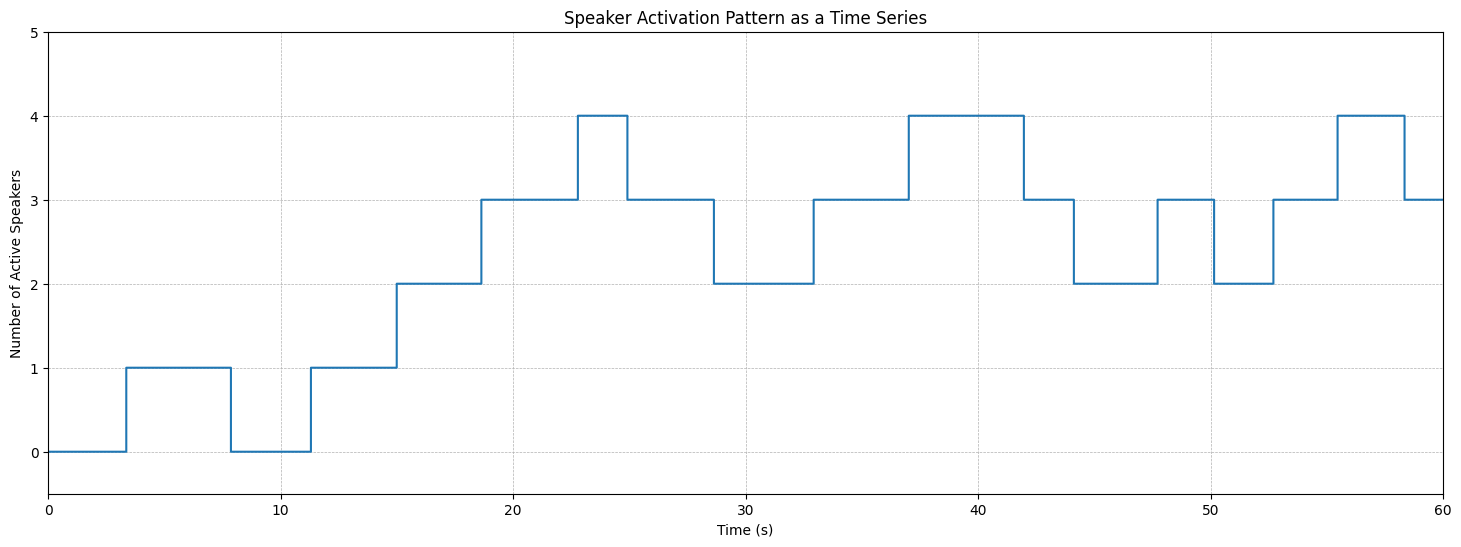

In [18]:
# 3. Plot the time series
time_vector = np.linspace(0, total_duration, time_series.shape[0])

plt.figure(figsize=(18, 6))
plt.step(time_vector, time_series.numpy(), where='post')
plt.title("Speaker Activation Pattern as a Time Series")
plt.xlabel("Time (s)")
plt.ylabel("Number of Active Speakers")
plt.yticks(range(max_speakers + 2))
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.ylim(bottom=-0.5)
plt.xlim(left=0, right=total_duration)
plt.show()

--- Event Transition Statistics ---
Transition 0 -> 1: 2 occurrences
Transition 1 -> 2: 1 occurrences
Transition 2 -> 3: 4 occurrences
Transition 3 -> 4: 3 occurrences
Transition 4 -> 3: 3 occurrences
Transition 3 -> 2: 3 occurrences
Transition 1 -> 0: 1 occurrences

--- Source Number Distribution (over time) ---
0 active speakers: 11.33% of the time
1 active speakers: 13.65% of the time
2 active speakers: 23.47% of the time
3 active speakers: 34.95% of the time
4 active speakers: 16.60% of the time


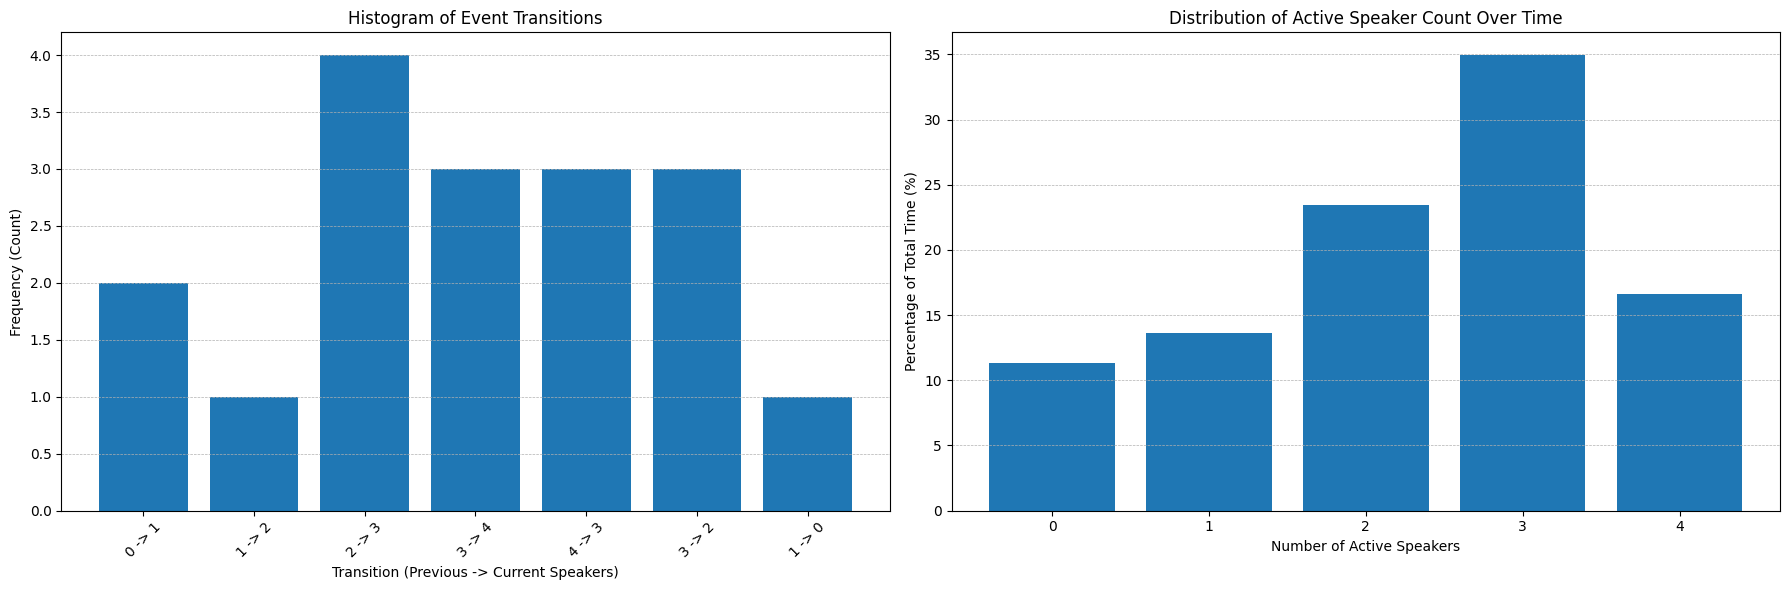

In [19]:
# 4. Calculate and plot statistics
from collections import Counter

# --- Event Transition Statistics ---
transitions = []
prev_num_sources = 0
for event in activation_pattern:
    current_num_sources = event['num_sources']
    transitions.append(f"{prev_num_sources} -> {current_num_sources}")
    prev_num_sources = current_num_sources

transition_counts = Counter(transitions)

# Define the custom sort order for transitions
activation_transitions = [f"{i} -> {i+1}" for i in range(max_speakers)]
deactivation_transitions = [f"{i} -> {i-1}" for i in range(max_speakers, 0, -1)]
custom_sort_order = activation_transitions + deactivation_transitions

# Sort the collected transitions based on the custom order
sorted_transition_items = sorted(
    transition_counts.items(),
    key=lambda item: custom_sort_order.index(item[0]) if item[0] in custom_sort_order else -1
)

print("--- Event Transition Statistics ---")
for transition, count in sorted_transition_items:
    print(f"Transition {transition}: {count} occurrences")

# --- Source Number Distribution Statistics ---
source_counts = torch.bincount(time_series)
source_distribution = source_counts.float() / time_series.numel()
print("\n--- Source Number Distribution (over time) ---")
for i, percentage in enumerate(source_distribution):
    print(f"{i} active speakers: {percentage:.2%} of the time")

# --- Plotting Histograms ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Subplot 1: Histogram of event transitions
if sorted_transition_items:
    labels, values = zip(*sorted_transition_items)
    ax1.bar(labels, values)
else:
    labels, values = [], []
ax1.set_title("Histogram of Event Transitions")
ax1.set_xlabel("Transition (Previous -> Current Speakers)")
ax1.set_ylabel("Frequency (Count)")
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', linestyle='--', linewidth=0.5)

# Subplot 2: Histogram of source number distribution
num_speakers = np.arange(len(source_distribution))
ax2.bar(num_speakers, source_distribution.numpy() * 100)
ax2.set_title("Distribution of Active Speaker Count Over Time")
ax2.set_xlabel("Number of Active Speakers")
ax2.set_ylabel("Percentage of Total Time (%)")
ax2.set_xticks(num_speakers)
ax2.grid(axis='y', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

Running simulation for 10000 activation patterns...
Simulation finished.

--- Aggregated Event Transition Statistics ---
Transition 0 -> 1: 33808 occurrences
Transition 1 -> 2: 25284 occurrences
Transition 2 -> 3: 19039 occurrences
Transition 3 -> 4: 15163 occurrences
Transition 4 -> 3: 13963 occurrences
Transition 3 -> 2: 15348 occurrences
Transition 2 -> 1: 19094 occurrences
Transition 1 -> 0: 25102 occurrences

--- Aggregated Source Number Distribution (over time) ---
0 active speakers: 20.09% of the time
1 active speakers: 30.08% of the time
2 active speakers: 22.90% of the time
3 active speakers: 18.48% of the time
4 active speakers: 8.46% of the time


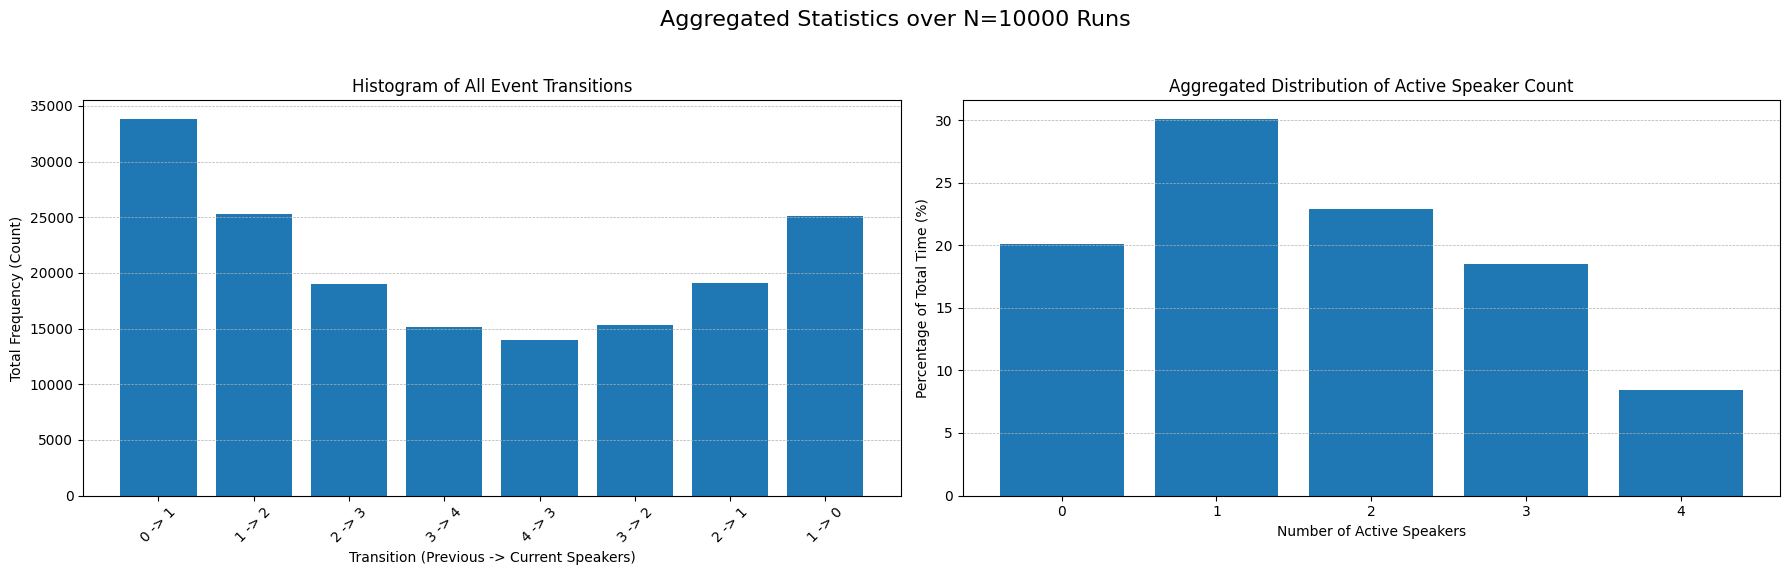

In [21]:
# 5. Run a large-scale simulation to verify the distributions
from collections import Counter
import numpy as np
import torch
import matplotlib.pyplot as plt

# --- Parameters for the large-scale test ---
N = 10000
total_duration = 60.0
sampling_frequency = 100
max_speakers = 4
time_between_events = (2.0, 5.0)
initial_noise_only_duration = (2.0, 5.0)

# --- Aggregators for statistics ---
total_transition_counts = Counter()
total_source_counts = torch.zeros(max_speakers + 1, dtype=torch.int64)
total_time_steps = 0

print(f"Running simulation for {N} activation patterns...")

# --- Loop to generate patterns and aggregate statistics ---
for _ in range(N):
    # Generate the activation pattern
    activation_pattern = generate_activation_pattern(
        max_speakers=max_speakers,
        total_duration=total_duration,
        time_between_events=time_between_events,
        initial_noise_only_duration=initial_noise_only_duration,
    )

    # Convert the pattern to a time series
    time_series = convert_pattern_to_time_series(
        activation_pattern=activation_pattern,
        total_duration=total_duration,
        sampling_frequency=sampling_frequency,
    )

    # Aggregate transition statistics
    prev_num_sources = 0
    for event in activation_pattern:
        current_num_sources = event['num_sources']
        total_transition_counts[f"{prev_num_sources} -> {current_num_sources}"] += 1
        prev_num_sources = current_num_sources

    # Aggregate source number distribution
    total_source_counts += torch.bincount(time_series, minlength=max_speakers + 1)
    total_time_steps += time_series.numel()

print("Simulation finished.")

# --- Calculate Final Distributions ---
# Sort transitions for plotting
activation_transitions = [f"{i} -> {i+1}" for i in range(max_speakers)]
deactivation_transitions = [f"{i} -> {i-1}" for i in range(max_speakers, 0, -1)]
custom_sort_order = activation_transitions + deactivation_transitions

sorted_transition_items = sorted(
    total_transition_counts.items(),
    key=lambda item: custom_sort_order.index(item[0]) if item[0] in custom_sort_order else -1
)

# Normalize source distribution
source_distribution = total_source_counts.float() / total_time_steps

# --- Print Statistics ---
print("\n--- Aggregated Event Transition Statistics ---")
for transition, count in sorted_transition_items:
    print(f"Transition {transition}: {count} occurrences")

print("\n--- Aggregated Source Number Distribution (over time) ---")
for i, percentage in enumerate(source_distribution):
    print(f"{i} active speakers: {percentage:.2%} of the time")


# --- Plotting Histograms ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(f'Aggregated Statistics over N={N} Runs', fontsize=16)

# Subplot 1: Histogram of event transitions
if sorted_transition_items:
    labels, values = zip(*sorted_transition_items)
    ax1.bar(labels, values)
else:
    labels, values = [], []
ax1.set_title("Histogram of All Event Transitions")
ax1.set_xlabel("Transition (Previous -> Current Speakers)")
ax1.set_ylabel("Total Frequency (Count)")
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', linestyle='--', linewidth=0.5)

# Subplot 2: Histogram of source number distribution
num_speakers = np.arange(len(source_distribution))
ax2.bar(num_speakers, source_distribution.numpy() * 100)
ax2.set_title("Aggregated Distribution of Active Speaker Count")
ax2.set_xlabel("Number of Active Speakers")
ax2.set_ylabel("Percentage of Total Time (%)")
ax2.set_xticks(num_speakers)
ax2.grid(axis='y', linestyle='--', linewidth=0.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
